Data: (361, 139)  Classes: {'AD': 81, 'CN': 108, 'MCI': 172}

APPROACH 1 — UMAP EMBEDDING → SVM / RF / XGB
✅ UMAP available
  UMAP(d=3) + SVM(RBF)                           Acc=0.471  Bal=0.562  MCC=0.303
  UMAP(d=3) + RF                                 Acc=0.476  Bal=0.444  MCC=0.145
  UMAP(d=3) + XGB                                Acc=0.465  Bal=0.449  MCC=0.138
  UMAP(d=5) + SVM(RBF)                           Acc=0.513  Bal=0.584  MCC=0.331
  UMAP(d=5) + RF                                 Acc=0.513  Bal=0.457  MCC=0.192
  UMAP(d=5) + XGB                                Acc=0.438  Bal=0.421  MCC=0.102
  UMAP(d=10) + SVM(RBF)                          Acc=0.507  Bal=0.590  MCC=0.341
  UMAP(d=10) + RF                                Acc=0.465  Bal=0.416  MCC=0.114
  UMAP(d=10) + XGB                               Acc=0.438  Bal=0.429  MCC=0.100
  UMAP(d=20) + SVM(RBF)                          Acc=0.510  Bal=0.585  MCC=0.332
  UMAP(d=20) + RF                                Acc=0.438  Bal=0.

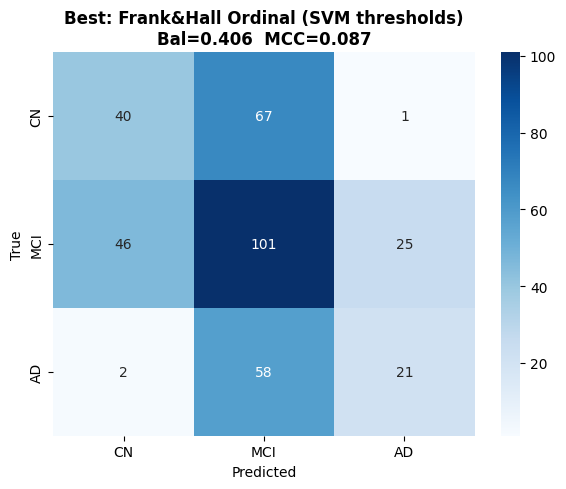


Done. Best result saved to nonlinear_best_cm.png


In [3]:
# ================================================================
# NON-LINEAR EXPERIMENTS — 3 approaches
# 1. UMAP → SVM
# 2. Polynomial interactions on top features
# 3. Ordinal classification (CN < MCI < AD)
# pip install umap-learn mord
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import RobustScaler, LabelEncoder, PolynomialFeatures
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              matthews_corrcoef, classification_report,
                              confusion_matrix)
from sklearn.decomposition import KernelPCA

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# ── Rebuild data ─────────────────────────────────────────────────
fs_df   = pd.read_csv('fastsurfer_features.csv')
clin_df = pd.read_csv('sonali/ALL_4_27_2026.csv')

fs_df['Base_Subject'] = fs_df['subject'].str.extract(r'(\d+_S_\d+)')
fs_df = fs_df.sort_values('subject').drop_duplicates(subset='Base_Subject', keep='first')
labels = clin_df.drop_duplicates('Subject')[['Subject','Group']].rename(
    columns={'Subject':'Base_Subject'})
merged = fs_df.merge(labels, on='Base_Subject', how='inner')

region_cols = [c for c in merged.columns if c.startswith('region_')]
X_raw = merged[region_cols].copy()
y_labels = merged['Group'].values

icv = X_raw['region_2000'] if 'region_2000' in X_raw.columns else X_raw.sum(axis=1)
X_raw = X_raw.drop(columns=['region_2000'], errors='ignore')
X_norm = X_raw.div(icv, axis=0).fillna(0)

# Engineered features (asymmetry + ratios)
asym = {}
for col in X_norm.columns:
    n = int(col.split('_')[1])
    if 1002 <= n <= 1035:
        rc = f'region_{n+1000}'
        if rc in X_norm.columns:
            L, R = X_norm[col], X_norm[rc]
            asym[f'asym_{n}'] = (L - R) / (L + R + 1e-10)
for l, r in [(4,43),(10,49),(11,50),(12,51),(13,52),(17,53),(18,54),(26,58),(28,60)]:
    lc, rc = f'region_{l}', f'region_{r}'
    if lc in X_norm.columns and rc in X_norm.columns:
        L, R = X_norm[lc], X_norm[rc]
        asym[f'asym_sub_{l}_{r}'] = (L - R) / (L + R + 1e-10)
ratios = {}
for s in [(17,4),(53,43)]:
    h, v = f'region_{s[0]}', f'region_{s[1]}'
    if h in X_norm.columns and v in X_norm.columns:
        ratios[f'hipp_vent_{s[0]}'] = X_norm[h] / (X_norm[v] + 1e-10)
temp = [c for c in X_norm.columns if int(c.split('_')[1]) in
        [1006,1007,1009,1015,1016,1030,1034,2006,2007,2009,2015,2016,2030,2034]]
front= [c for c in X_norm.columns if int(c.split('_')[1]) in
        [1003,1012,1014,1018,1019,1020,1027,1028,2003,2012,2014,2018,2019,2020,2027,2028]]
if temp and front:
    ratios['temporal_frontal'] = X_norm[temp].sum(axis=1) / (X_norm[front].sum(axis=1) + 1e-10)
vc = [c for c in X_norm.columns if int(c.split('_')[1]) in [4,5,14,15,43,44]]
if vc: ratios['ventricle_index'] = X_norm[vc].sum(axis=1)

X_eng = pd.concat([X_norm,
                   pd.DataFrame(asym, index=X_norm.index),
                   pd.DataFrame(ratios, index=X_norm.index)],
                  axis=1).fillna(0)
X_arr = X_eng.values
feature_names = X_eng.columns.tolist()

le = LabelEncoder()
y_enc = le.fit_transform(y_labels)   # AD=0, CN=1, MCI=2
print(f"Data: {X_arr.shape}  Classes: {dict(zip(le.classes_, np.bincount(y_enc)))}")


# ================================================================
# HELPER — 5-fold CV with pre-scaling
# ================================================================
def eval_model(clf, X, y, label, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accs, baccs, mccs = [], [], []
    yt_all, yp_all = [], []
    for tr, te in skf.split(X, y):
        sc = RobustScaler()
        Xtr = sc.fit_transform(X[tr]); Xte = sc.transform(X[te])
        mdl = clone(clf); mdl.fit(Xtr, y[tr])
        yp = mdl.predict(Xte)
        accs.append(accuracy_score(y[te], yp))
        baccs.append(balanced_accuracy_score(y[te], yp))
        mccs.append(matthews_corrcoef(y[te], yp))
        yt_all.extend(y[te]); yp_all.extend(yp)
    print(f"  {label:<45}  Acc={np.mean(accs):.3f}  "
          f"Bal={np.mean(baccs):.3f}  MCC={np.mean(mccs):.3f}")
    return {'label': label, 'acc': np.mean(accs),
            'bal': np.mean(baccs), 'mcc': np.mean(mccs),
            'y_true': np.array(yt_all), 'y_pred': np.array(yp_all)}


# ================================================================
# APPROACH 1 — UMAP → CLASSIFY
# ================================================================
print("\n" + "="*60)
print("APPROACH 1 — UMAP EMBEDDING → SVM / RF / XGB")
print("="*60)

try:
    import umap
    HAS_UMAP = True
    print("✅ UMAP available")
except ImportError:
    HAS_UMAP = False
    print("⚠️  UMAP not installed.  Run:  pip install umap-learn")
    print("   Skipping UMAP section.")

umap_results = []
if HAS_UMAP:
    skf_u = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for n_comp in [3, 5, 10, 20]:
        for clf_name, clf_obj in [
            ('SVM(RBF)', SVC(kernel='rbf', C=10, class_weight='balanced',
                             probability=True, random_state=42)),
            ('RF',       RandomForestClassifier(n_estimators=300, max_depth=8,
                                                class_weight='balanced', random_state=42)),
            ('XGB',      XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                       use_label_encoder=False, eval_metric='mlogloss',
                                       random_state=42) if HAS_XGB else
                         GradientBoostingClassifier(n_estimators=200, random_state=42)),
        ]:
            accs, baccs, mccs = [], [], []
            for tr, te in skf_u.split(X_arr, y_enc):
                sc = RobustScaler()
                Xtr_s = sc.fit_transform(X_arr[tr])
                Xte_s = sc.transform(X_arr[te])

                # Fit UMAP on training only
                reducer = umap.UMAP(n_components=n_comp, random_state=42,
                                    n_neighbors=15, min_dist=0.1)
                Xtr_u = reducer.fit_transform(Xtr_s)
                Xte_u = reducer.transform(Xte_s)

                mdl = clone(clf_obj); mdl.fit(Xtr_u, y_enc[tr])
                yp = mdl.predict(Xte_u)
                accs.append(accuracy_score(y_enc[te], yp))
                baccs.append(balanced_accuracy_score(y_enc[te], yp))
                mccs.append(matthews_corrcoef(y_enc[te], yp))

            label = f"UMAP(d={n_comp}) + {clf_name}"
            r = {'label': label, 'acc': np.mean(accs),
                 'bal': np.mean(baccs), 'mcc': np.mean(mccs)}
            umap_results.append(r)
            print(f"  {label:<45}  Acc={r['acc']:.3f}  Bal={r['bal']:.3f}  MCC={r['mcc']:.3f}")

    best_umap = max(umap_results, key=lambda x: x['bal'])
    print(f"\n★ Best UMAP config: {best_umap['label']}")
    print(f"  Acc={best_umap['acc']:.3f}  Bal={best_umap['bal']:.3f}  MCC={best_umap['mcc']:.3f}")


# ================================================================
# APPROACH 2 — POLYNOMIAL FEATURE INTERACTIONS
# ================================================================
print("\n" + "="*60)
print("APPROACH 2 — POLYNOMIAL INTERACTIONS ON TOP FEATURES")
print("="*60)

# Use top 15 most important features (from RF importance earlier)
# These are the key AD-related regions
TOP_REGIONS = [
    'region_17', 'region_18', 'region_53', 'region_54',   # Hippocampus + Amygdala
    'region_4',  'region_43',                               # Lateral ventricles
    'region_2006','region_1006',                            # Entorhinal
    'region_2007','region_1007',                            # Fusiform
    'hipp_vent_17', 'hipp_vent_53',                        # Ratios
    'temporal_frontal', 'ventricle_index',                  # Derived
    'region_44', 'region_5',                               # Inf lateral ventricle
]
top_cols = [c for c in TOP_REGIONS if c in feature_names]
X_top = X_eng[top_cols].values
print(f"Using {len(top_cols)} top features for polynomial expansion")

poly_results = []
for degree in [2, 3]:
    # Degree 2 gives interactions like hipp × ventricle
    # Degree 3 gives triple interactions
    poly = PolynomialFeatures(degree=degree, interaction_only=False, include_bias=False)

    for clf_name, clf_obj in [
        ('SVM(RBF)',  SVC(kernel='rbf', C=10, class_weight='balanced',
                          probability=True, random_state=42)),
        ('LR(L2)',    LogisticRegression(C=0.1, max_iter=2000,
                                         class_weight='balanced', random_state=42)),
        ('RF',        RandomForestClassifier(n_estimators=300, max_depth=6,
                                              class_weight='balanced', random_state=42)),
    ]:
        skf_p = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        accs, baccs, mccs = [], [], []
        for tr, te in skf_p.split(X_top, y_enc):
            sc = RobustScaler()
            Xtr_s = sc.fit_transform(X_top[tr])
            Xte_s = sc.transform(X_top[te])
            # Expand polynomial (on scaled data)
            Xtr_p = poly.fit_transform(Xtr_s)
            Xte_p = poly.transform(Xte_s)
            # Scale again after expansion
            sc2 = RobustScaler()
            Xtr_p = sc2.fit_transform(Xtr_p)
            Xte_p = sc2.transform(Xte_p)

            mdl = clone(clf_obj); mdl.fit(Xtr_p, y_enc[tr])
            yp = mdl.predict(Xte_p)
            accs.append(accuracy_score(y_enc[te], yp))
            baccs.append(balanced_accuracy_score(y_enc[te], yp))
            mccs.append(matthews_corrcoef(y_enc[te], yp))

        n_poly_feats = poly.fit_transform(np.zeros((1, len(top_cols)))).shape[1]
        label = f"Poly(deg={degree}, {n_poly_feats}f) + {clf_name}"
        r = {'label': label, 'acc': np.mean(accs),
             'bal': np.mean(baccs), 'mcc': np.mean(mccs)}
        poly_results.append(r)
        print(f"  {label:<50}  Acc={r['acc']:.3f}  Bal={r['bal']:.3f}  MCC={r['mcc']:.3f}")

best_poly = max(poly_results, key=lambda x: x['bal'])
print(f"\n★ Best Polynomial config: {best_poly['label']}")
print(f"  Acc={best_poly['acc']:.3f}  Bal={best_poly['bal']:.3f}  MCC={best_poly['mcc']:.3f}")


# ================================================================
# APPROACH 3 — ORDINAL CLASSIFICATION (CN=0 < MCI=1 < AD=2)
# ================================================================
print("\n" + "="*60)
print("APPROACH 3 — ORDINAL CLASSIFICATION (CN < MCI < AD)")
print("="*60)

# Ordinal encoding: CN=0, MCI=1, AD=2
ordinal_map = {'CN': 0, 'MCI': 1, 'AD': 2}
y_ord = np.array([ordinal_map[g] for g in y_labels])

try:
    from mord import LogisticAT, LogisticIT, OrdinalRidge
    HAS_MORD = True
    print("✅ mord (ordinal) available")
except ImportError:
    HAS_MORD = False
    print("⚠️  mord not installed.  Run:  pip install mord")

ordinal_results = []

# ── Method A: Ordinal logistic (mord library) ───────────────────
if HAS_MORD:
    for alpha in [0.1, 1.0, 10.0]:
        accs, baccs, mccs = [], [], []
        skf_o = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        for tr, te in skf_o.split(X_arr, y_ord):
            sc = RobustScaler()
            Xtr = sc.fit_transform(X_arr[tr]); Xte = sc.transform(X_arr[te])
            mdl = LogisticAT(alpha=alpha)
            mdl.fit(Xtr, y_ord[tr])
            yp = mdl.predict(Xte)
            accs.append(accuracy_score(y_ord[te], yp))
            baccs.append(balanced_accuracy_score(y_ord[te], yp))
            mccs.append(matthews_corrcoef(y_ord[te], yp))
        label = f"OrdinalLogistic(alpha={alpha})"
        r = {'label': label, 'acc': np.mean(accs),
             'bal': np.mean(baccs), 'mcc': np.mean(mccs)}
        ordinal_results.append(r)
        print(f"  {label:<45}  Acc={r['acc']:.3f}  Bal={r['bal']:.3f}  MCC={r['mcc']:.3f}")

# ── Method B: Threshold-based ordinal decomposition ─────────────
# Train binary classifier for each threshold:
#   Clf1: CN (0) vs (MCI+AD) (1+2)
#   Clf2: (CN+MCI) (0+1) vs AD (2)
# Combine: P(MCI) = P(>CN) - P(>MCI) etc.
print("\n  -- Threshold decomposition (Frank & Hall method) --")

skf_th = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs_th, baccs_th, mccs_th = [], [], []
yt_th, yp_th = [], []

for tr, te in skf_th.split(X_arr, y_ord):
    sc = RobustScaler()
    Xtr = sc.fit_transform(X_arr[tr]); Xte = sc.transform(X_arr[te])

    # Threshold 1: P(y > 0)  i.e. P(MCI or AD)
    y_t1_tr = (y_ord[tr] > 0).astype(int)
    clf1 = SVC(kernel='rbf', C=10, class_weight='balanced',
               probability=True, random_state=42)
    clf1.fit(Xtr, y_t1_tr)
    p_gt0 = clf1.predict_proba(Xte)[:, 1]   # P(y > CN)

    # Threshold 2: P(y > 1)  i.e. P(AD)
    y_t2_tr = (y_ord[tr] > 1).astype(int)
    clf2 = SVC(kernel='rbf', C=10, class_weight='balanced',
               probability=True, random_state=42)
    clf2.fit(Xtr, y_t2_tr)
    p_gt1 = clf2.predict_proba(Xte)[:, 1]   # P(y > MCI)

    # Convert to class probabilities
    p_cn  = 1 - p_gt0               # P(CN)
    p_mci = p_gt0 - p_gt1           # P(MCI) — clamp to 0
    p_mci = np.maximum(p_mci, 0)
    p_ad  = p_gt1                    # P(AD)

    # Stack and argmax → maps 0=CN, 1=MCI, 2=AD
    probs = np.stack([p_cn, p_mci, p_ad], axis=1)
    yp = np.argmax(probs, axis=1)

    accs_th.append(accuracy_score(y_ord[te], yp))
    baccs_th.append(balanced_accuracy_score(y_ord[te], yp))
    mccs_th.append(matthews_corrcoef(y_ord[te], yp))
    yt_th.extend(y_ord[te]); yp_th.extend(yp)

r_th = {'label': 'Frank&Hall Ordinal (SVM thresholds)',
        'acc': np.mean(accs_th), 'bal': np.mean(baccs_th), 'mcc': np.mean(mccs_th),
        'y_true': np.array(yt_th), 'y_pred': np.array(yp_th)}
ordinal_results.append(r_th)
print(f"  {r_th['label']:<45}  Acc={r_th['acc']:.3f}  "
      f"Bal={r_th['bal']:.3f}  MCC={r_th['mcc']:.3f}")
print(f"\n  Classification report:")
print(classification_report(r_th['y_true'], r_th['y_pred'],
                             target_names=['CN','MCI','AD']))

best_ord = max(ordinal_results, key=lambda x: x['bal'])
print(f"★ Best Ordinal config: {best_ord['label']}")
print(f"  Acc={best_ord['acc']:.3f}  Bal={best_ord['bal']:.3f}  MCC={best_ord['mcc']:.3f}")


# ================================================================
# FINAL COMPARISON TABLE
# ================================================================
print("\n" + "="*60)
print("FINAL COMPARISON — ALL NON-LINEAR APPROACHES")
print("="*60)

all_r = []
if HAS_UMAP and umap_results:
    all_r.append(best_umap)
all_r.extend(poly_results)
all_r.extend(ordinal_results)

# Add baselines
all_r += [
    {'label': '--- BASELINES ---', 'acc': 0, 'bal': 0, 'mcc': 0},
    {'label': 'LR raw volumes', 'acc': 0.529, 'bal': 0.566, 'mcc': 0.302},
    {'label': 'RF engineered',  'acc': 0.562, 'bal': 0.553, 'mcc': 0.304},
]

print(f"\n{'Approach':<52} {'Acc':>6} {'Bal':>6} {'MCC':>6}")
print("-"*68)
for r in sorted([x for x in all_r if x['bal'] > 0], key=lambda x: x['bal'], reverse=True):
    marker = '★' if r['bal'] == max(x['bal'] for x in all_r if x['bal'] > 0) else ' '
    print(f"{marker} {r['label']:<51} {r['acc']:>6.3f} {r['bal']:>6.3f} {r['mcc']:>6.3f}")

# Best confusion matrix
best_overall = max([r for r in all_r if r['bal'] > 0 and 'y_true' in r],
                    key=lambda x: x['bal'], default=r_th)

cm_final = confusion_matrix(best_overall['y_true'], best_overall['y_pred'])
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['CN','MCI','AD'], yticklabels=['CN','MCI','AD'])
ax.set_title(f"Best: {best_overall['label']}\n"
             f"Bal={best_overall['bal']:.3f}  MCC={best_overall['mcc']:.3f}",
             fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('nonlinear_best_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nDone. Best result saved to nonlinear_best_cm.png")


In [2]:
!pip install mord

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mord: filename=mord-0.7-py3-none-any.whl size=9953 sha256=67a897459813456a74dbf040aaff78aeae4ae3173084c2bebe35b7724ecb527e
  Stored in directory: /tmp/pip-ephem-wheel-cache-bpahlbcx/wheels/77/00/19/3cea86fbfc737ec4acb515cd94497dcc33f943fa157548b96c
Successfully built mord
